<a href="https://colab.research.google.com/github/Tejeshwini89/Computer-Vision/blob/main/geometric%20transformations%20(translation%2C%20scaling%2C%20rotation)%20and%20basic%20image%20operations%20(grayscale%2C%20simple%20filters).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

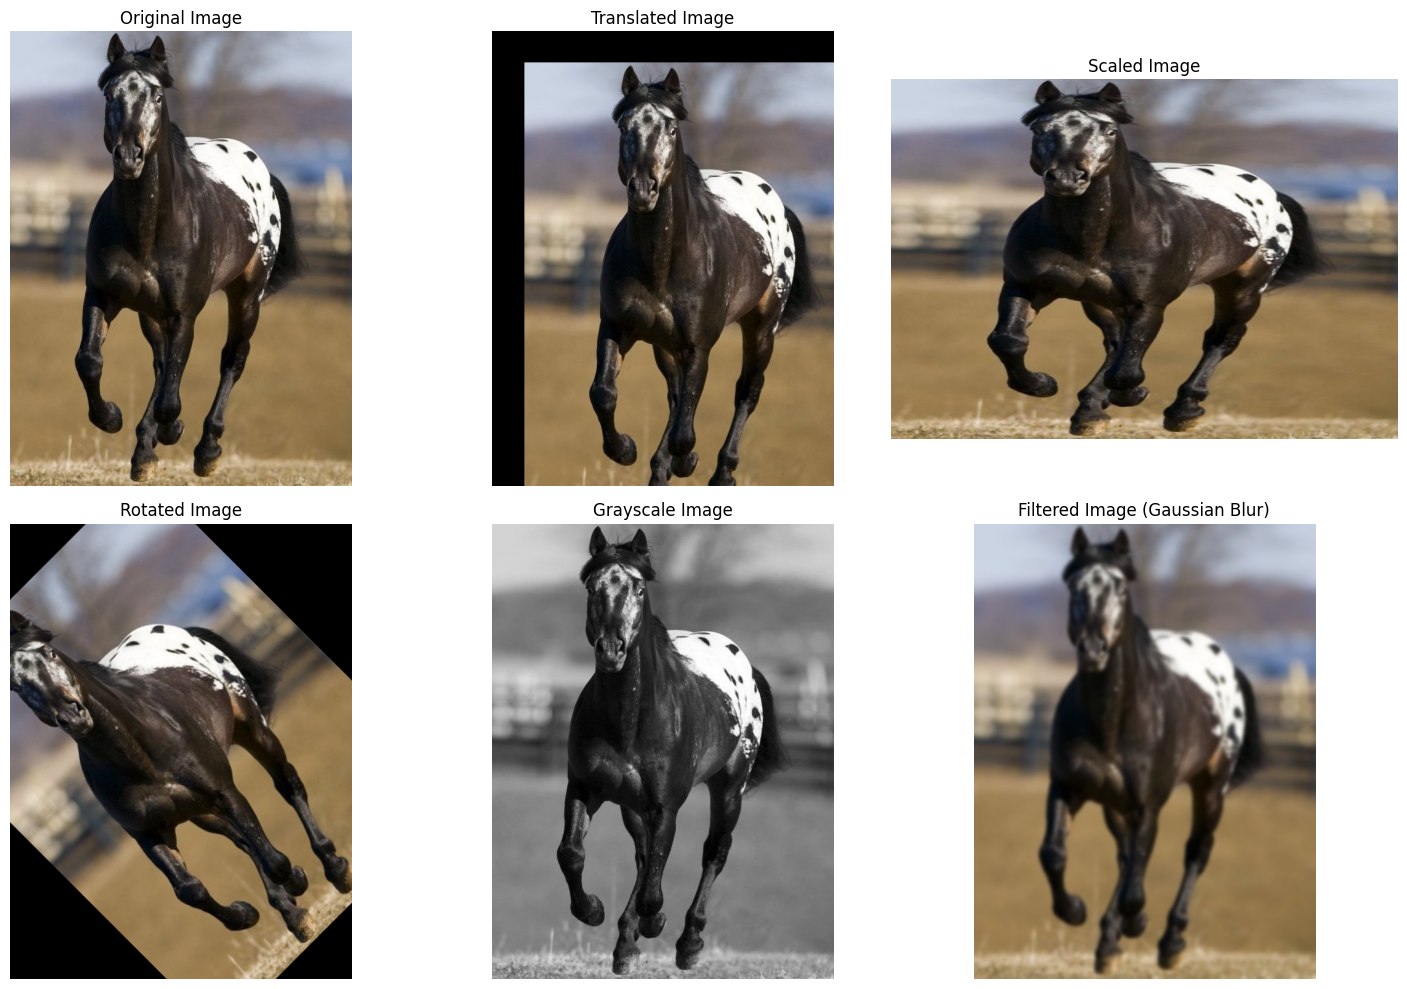

In [ ]:
"""Task:Implement geometric transformations (translation, scaling, rotation) and basic image operations (grayscale, simple filters) for both images and video frames using OpenCV and NumPy."""

%pip install opencv-python numpy
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # Import cv2_imshow for compatibility if needed

# 1. Load an image
image_path = '/content/H.jpg'
try:
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
except FileNotFoundError as e:
    print(e)
    # Create a dummy image if loading fails
    image = np.zeros((300, 400, 3), dtype=np.uint8)
    cv2.putText(image, "Image not found, displaying a dummy image", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)


height, width = image.shape[:2]

# 2. Implement translation
tx, ty = 50, 50 # Translation values
translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
translated_image = cv2.warpAffine(image, translation_matrix, (width, height))

# 3. Implement scaling
scale_factor_x = 1.5
scale_factor_y = 0.8
scaled_image = cv2.resize(image, None, fx=scale_factor_x, fy=scale_factor_y, interpolation=cv2.INTER_LINEAR)

# 4. Implement rotation
center = (width // 2, height // 2)
angle = 45 # Rotation angle in degrees
rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))

# 5. Convert to grayscale
grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 6. Apply Gaussian blur filter
filtered_image = cv2.GaussianBlur(image, (15, 15), 0)

# 7. Display images using matplotlib
images = [image, translated_image, scaled_image, rotated_image, grayscale_image, filtered_image]
titles = ['Original Image', 'Translated Image', 'Scaled Image', 'Rotated Image', 'Grayscale Image', 'Filtered Image (Gaussian Blur)']

plt.figure(figsize=(15, 10))
for i, img in enumerate(images):
    plt.subplot(2, 3, i + 1)
    if len(img.shape) == 2: # Check if grayscale
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# No need for cv2.waitKey() and cv2.destroyAllWindows() when using matplotlib

In [ ]:
import cv2
import numpy as np

# 2. Create a dummy video writer
output_filename = '/content/12469452_2160_3840_30fps.mp4'
fourcc = cv2.VideoWriter_fourcc(*'XVID')
fps = 20.0
frame_size = (400, 300) # Match dummy image size from previous step

out = cv2.VideoWriter(output_filename, fourcc, fps, frame_size)

# 3. Create a loop to generate dummy frames
num_frames = 100

for i in range(num_frames):
    # Create a dummy image representing a frame
    frame = np.zeros((300, 400, 3), dtype=np.uint8)
    text = f"Frame: {i+1}"
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # 4. Apply geometric transformations and basic image operations
    # Apply translation
    tx, ty = 5 + i, 5 + i # Dynamic translation
    translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    translated_frame = cv2.warpAffine(frame, translation_matrix, frame_size)

    # Apply scaling (scaling the translated frame)
    scale_factor_x = 1.0 + (i * 0.01) # Dynamic scaling
    scale_factor_y = 1.0 - (i * 0.005) # Dynamic scaling
    scaled_frame = cv2.resize(translated_frame, None, fx=scale_factor_x, fy=scale_factor_y, interpolation=cv2.INTER_LINEAR)

    # Apply rotation (rotating the scaled frame)
    center = (scaled_frame.shape[1] // 2, scaled_frame.shape[0] // 2)
    angle = i # Dynamic rotation
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    # Adjust frame size for rotation to avoid cropping
    rotated_frame = cv2.warpAffine(scaled_frame, rotation_matrix, (scaled_frame.shape[1], scaled_frame.shape[0]))

    # Convert to grayscale (converting the rotated frame)
    grayscale_frame = cv2.cvtColor(rotated_frame, cv2.COLOR_BGR2GRAY)
    # Convert grayscale back to BGR to write to color video
    grayscale_frame_bgr = cv2.cvtColor(grayscale_frame, cv2.COLOR_GRAY2BGR)


    # Apply Gaussian blur filter (applying to the grayscale BGR frame)
    processed_frame = cv2.GaussianBlur(grayscale_frame_bgr, (15, 15), 0)

    # Ensure the processed frame has the correct size before writing
    processed_frame_resized = cv2.resize(processed_frame, frame_size)


    # 5. Write the processed frame
    out.write(processed_frame_resized)

# 6. Release the video writer
out.release()

# 7. Print completion message
print(f"Processed video saved as {output_filename}")

Processed video saved as /content/12469452_2160_3840_30fps.mp4
